In [13]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [14]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/data_labelled.csv"

In [15]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [16]:
df.columns 

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

<h3> Irrelevant Columns

In [17]:
irrelevant = ['User_ID']

In [18]:
df = df.drop(columns=irrelevant)

<h3> Encoding Target Variable </h3>

In [19]:
le = LabelEncoder()
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])

In [20]:
df.Stress_Level.value_counts()

Stress_Level
0    19950
2    15043
1    15007
Name: count, dtype: int64

In [21]:
X = df.drop('Stress_Level', axis=1)
y = df['Stress_Level']

In [22]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> Logistic Regression Training 

In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [33]:
y_pred_log = log_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [34]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.3354
              precision    recall  f1-score   support

           0       0.40      0.31      0.35      5985
           1       0.30      0.37      0.33      4502
           2       0.32      0.33      0.32      4513

    accuracy                           0.34     15000
   macro avg       0.34      0.34      0.33     15000
weighted avg       0.34      0.34      0.34     15000



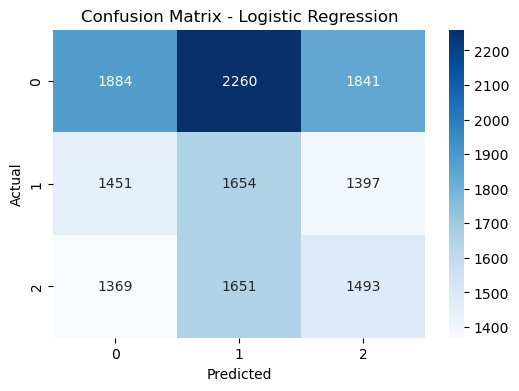

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()